# Locked 2025 temporal confirmation

This is the single frozen confirmation evaluation defined in [the forecasting protocol](../docs/forecasts.md). Earlier full-sample descriptive EDA included 2025, so this is a locked temporal confirmation sample, not a perfectly pristine unseen holdout. The development choices are fixed: M6 Elastic Net for five-session 30D skew change and M2 mean reversion for five-session 30D–60D skew-spread change. No specification or hyperparameter is changed after viewing these results.

## Freeze models using development data only

Development inputs end on 2024-12-31. The M6 hyperparameter grid is selected with the final two purged 30-session validation blocks, and the final scaler and model use only development labels matured by that date. The two M2 fits are also development-only. Nothing in this section uses a 2025 outcome.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.forecasting import (
    DEV_END, HOLDOUT_END, build_linear_development_dataset,
    build_locked_feature_panel, build_locked_outcomes, cumulative_locked_gains,
    fit_locked_models, forecast_locked_holdout, score_locked_holdout,
)
from src.time_series import load_skew_metrics

metrics = load_skew_metrics(project_root / 'data/processed/spx_skew_metrics_2023_2025.csv')
spx_prices = pd.read_csv(project_root / 'data/raw/spx_security_prices.csv')
vix_prices = pd.read_csv(project_root / 'data/raw/VIX_security_prices.csv')
dev_metrics = metrics.loc[metrics.quote_date.le(DEV_END)].copy()
dev_spx = spx_prices.loc[pd.to_datetime(spx_prices.date).le(DEV_END)].copy()
dev_vix = vix_prices.loc[pd.to_datetime(vix_prices.date).le(DEV_END)].copy()
development = build_linear_development_dataset(dev_metrics, dev_spx, dev_vix)
fitted = fit_locked_models(development, dev_spx)

display(pd.Series({
    'development sessions': len(development),
    'last matured target origin': fitted['last_matured_origin'].date(),
    'selected M6 alpha': fitted['m6_alpha'],
    'selected M6 l1_ratio': fitted['m6_l1_ratio'],
    'M6 complete matured training rows': fitted['m6_n_train'],
}))
display(pd.DataFrame([
    {'alpha': alpha, 'l1_ratio': l1_ratio, 'pooled_inner_rmse': rmse}
    for (alpha, l1_ratio), rmse in fitted['m6_inner_rmse'].items()
]))
display(pd.DataFrame(fitted['m2_coefficients']).T.rename_axis('target'))

development sessions                        502
last matured target origin           2024-12-23
selected M6 alpha                          0.01
selected M6 l1_ratio                       0.25
M6 complete matured training rows           422
dtype: object

,alpha,l1_ratio,pooled_inner_rmse
0,0.0001,0.25,0.104205
1,0.0001,0.75,0.103704
2,0.0010,0.25,0.101004
3,0.0010,0.75,0.097373
4,0.0100,0.25,0.089411
5,0.0100,0.75,0.089777


,intercept,slope,n_train
target,,,
y_skew_30_5d,0.007266,-0.040897,435.0
y_skew_spread_5d,0.004940,-0.027615,429.0


## Generate locked predictions before constructing outcomes

Causal surface and market features use the full SPX session sequence, with exact-date market joins and past-only expanding z-scores. The prediction API takes no realised 2025 target column. The fitted scaler, M6 coefficients, hyperparameters and M2 coefficients remain static throughout 2025.

In [2]:
features = build_locked_feature_panel(metrics, spx_prices, vix_prices)
assert not any(column.startswith('y_') for column in features)
predictions = forecast_locked_holdout(fitted, features, spx_prices)
assert all(frame.quote_date.max() == HOLDOUT_END for frame in predictions.values())
display(pd.DataFrame([
    {'target': target, '2025_sessions': len(frame),
     'first_date': frame.quote_date.min().date(),
     'last_date': frame.quote_date.max().date(),
     'm0_forecasts': int(frame.m0_persistence.notna().sum()),
     'm2_forecasts': int(frame.m2_mean_reversion.notna().sum()),
     'm6_forecasts': int(frame.m6_elastic_net.notna().sum()) if 'm6_elastic_net' in frame else None}
    for target, frame in predictions.items()
]))

,target,2025_sessions,first_date,last_date,m0_forecasts,m2_forecasts,m6_forecasts
0,y_skew_30_5d,165,2025-01-02,2025-08-29,165,165,163.0
1,y_skew_spread_5d,165,2025-01-02,2025-08-29,164,164,NaN


## Score on common realised confirmation dates

Only now are five-session 2025 outcomes constructed. The final five sessions have no observable within-sample endpoint. Each target's headline table uses dates on which its realised outcome and every benchmark/selected-model forecast exist; no missing value is filled.

In [3]:
outcomes = build_locked_outcomes(features, spx_prices)
assert outcomes.tail(5)[['y_skew_30_5d', 'y_skew_spread_5d']].isna().all().all()
scored = {
    target: score_locked_holdout(frame, outcomes, target)
    for target, frame in predictions.items()
}
coverage = pd.DataFrame([
    {'target': target,
     '2025_sessions': len(frame),
     'realised_targets': int(outcomes[target].notna().sum()),
     'common_scored_dates': len(scored[target][1]),
     'first_scored_date': scored[target][1].quote_date.min().date(),
     'last_scored_date': scored[target][1].quote_date.max().date()}
    for target, frame in predictions.items()
])
display(coverage)
for target, (summary, _) in scored.items():
    print(target)
    shown = summary.copy()
    numeric = shown.select_dtypes(include='number').columns
    shown[numeric] = shown[numeric].round(4)
    display(shown)

,target,2025_sessions,realised_targets,common_scored_dates,first_scored_date,last_scored_date
0,y_skew_30_5d,165,160,158,2025-01-02,2025-08-22
1,y_skew_spread_5d,165,158,158,2025-01-02,2025-08-22


y_skew_30_5d


,model,n_common,first_date,last_date,rmse,mae,correlation,directional_accuracy,r2_vs_persistence,r2_vs_mean_reversion
0,m0_persistence,158,2025-01-02,2025-08-22,0.1012,0.0737,NaN,NaN,0.0000,NaN
1,m2_mean_reversion,158,2025-01-02,2025-08-22,0.0922,0.0657,0.5766,0.6013,0.1695,NaN
2,m6_elastic_net,158,2025-01-02,2025-08-22,0.1081,0.0737,0.4164,0.6013,-0.1404,-0.3731


y_skew_spread_5d


,model,n_common,first_date,last_date,rmse,mae,correlation,directional_accuracy,r2_vs_persistence,r2_vs_mean_reversion
0,m0_persistence,158,2025-01-02,2025-08-22,0.0544,0.0421,NaN,NaN,0.0000,NaN
1,m2_mean_reversion,158,2025-01-02,2025-08-22,0.0492,0.0368,0.5619,0.6203,0.1824,NaN


## Cumulative squared-error gains

The 30D plot shows M2 versus M0, M6 versus M0, and M6 versus the frozen M2. The spread plot shows M2 versus M0. Each curve uses its target's common scored dates; positive values favour the named model.

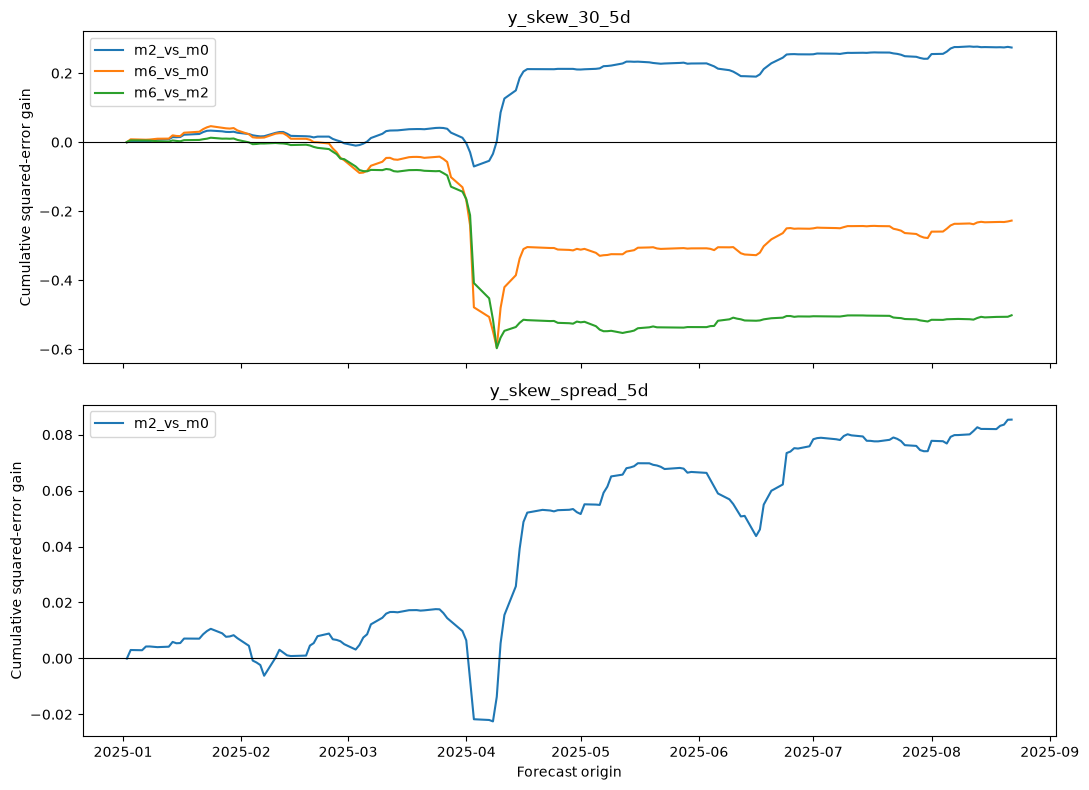

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, (target, (_, common)) in zip(axes, scored.items()):
    gains = cumulative_locked_gains(common, target)
    for column in gains.columns.drop('quote_date'):
        ax.plot(gains.quote_date, gains[column], label=column)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(target)
    ax.set_ylabel('Cumulative squared-error gain')
    ax.legend()
axes[-1].set_xlabel('Forecast origin')
fig.tight_layout()
plt.show()

## Interpretation

The single frozen run selected M6 `alpha=0.01`, `l1_ratio=0.25` from development data. On 158 common scored 2025 dates, the 30D M6 forecast has RMSE 0.1081 versus 0.0922 for frozen M2 and 0.1012 for persistence; its $R^2$ versus M2 is -0.3731. **M6 did not confirm incremental value** for outright 30D skew. For the 30D–60D spread, frozen M2 has RMSE 0.0492 versus 0.0544 for persistence and $R^2$ versus persistence of 0.1824, confirming improvement on that benchmark. The 165-session confirmation panel yields 160 available outright labels, 158 spread labels, and 158 common scored dates for each headline comparison. M6 abstains on two predictor-incomplete sessions; one spread state is unavailable, and the final five sessions have no observable five-session endpoint. No missing values were filled. Five-session outcomes overlap, so these descriptive comparisons are not iid significance tests or evidence of executable trading profitability.